In [1]:
pip install pandas numpy matplotlib scikit-learn torch transformers hf_xet peft

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from torch import cuda
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    auc
)

from sklearn.metrics import classification_report, roc_auc_score
import torch
import os
from tqdm.auto import tqdm

In [3]:
# Load data
df = pd.read_csv('./dataset/heart_diagnoses.csv')
procedures = pd.read_csv('./dataset/heart_procedures.csv')
diagnosis = pd.read_csv('./dataset/heart_diagnoses_all_true.csv')
labs = pd.read_csv('./dataset/heart_labevents_first_lab.csv')


## EDA for MI patients

How many MI patients who have complete data from HPI (or can be replaced by chief complaints and physical examination), ECG clinician-generated report, Troponin-T lab result, and CATH report?

In [4]:
# 1. Filter to MI patients (I21, I22)
mi_codes = diagnosis[diagnosis['icd_code'].str.startswith(('I21', 'I22'))]
mi_patients = df[df['hadm_id'].isin(mi_codes['hadm_id'])]
print(f"MI patients: {len(mi_patients)}")

MI patients: 1560


In [5]:
# 2. Check who got CATH
# Use keyword "cath" in ICD_code long_title in heart_procedures.csv
icd_code_cath = ['3722', '8856', '3723', '3721', '3897', '3893', '3891', '3726', '3895', '8855', '3404', '5794', '598']
cath_procedures = procedures[procedures['icd_code'].astype(str).isin(icd_code_cath)]

mi_patients['got_cath'] = mi_patients['hadm_id'].isin(cath_procedures['hadm_id'])
print(f"MI patients who got CATH: {mi_patients['got_cath'].sum()} ({mi_patients['got_cath'].mean()*100:.1f}%)")


MI patients who got CATH: 968 (62.1%)


/tmp/ipython-input-1609565979.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mi_patients['got_cath'] = mi_patients['hadm_id'].isin(cath_procedures['hadm_id'])


In [6]:
## Double check!
# Check how many patients who have a valid CATH report from heart_diagnoses.csv
cath_report = df[~(df['CATH'].str.contains(r'(not available|pending|\[\])', case=False, na=False) & (df['CATH'].str.len() < 200))]

mi_patients['cath_report'] = mi_patients['hadm_id'].isin(cath_report['hadm_id'])
print(f"MI patients who have CATH report: {mi_patients['got_cath'].sum()} ({mi_patients['got_cath'].mean()*100:.1f}%)")

MI patients who have CATH report: 968 (62.1%)


/tmp/ipython-input-1308324954.py:3: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  cath_report = df[~(df['CATH'].str.contains(r'(not available|pending|\[\])', case=False, na=False) & (df['CATH'].str.len() < 200))]
/tmp/ipython-input-1308324954.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mi_patients['cath_report'] = mi_patients['hadm_id'].isin(cath_report['hadm_id'])


Both methods are reliable to produce the same amount of result.

In [7]:
# 3. Check ECG availability
mi_patients['has_ecg'] = mi_patients['ECG'].str.contains(r'\[\]', case=False, na=False)  # clinician report
mi_patients['has_ecg_machine'] = mi_patients['reports'].notna()  # machine report
print(f"Has clinician ECG: {mi_patients['has_ecg'].sum()}")
print(f"Has machine ECG: {mi_patients['has_ecg_machine'].sum()}")


Has clinician ECG: 564
Has machine ECG: 1560


/tmp/ipython-input-473121965.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mi_patients['has_ecg'] = mi_patients['ECG'].str.contains(r'\[\]', case=False, na=False)  # clinician report
/tmp/ipython-input-473121965.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mi_patients['has_ecg_machine'] = mi_patients['reports'].notna()  # machine report


In [8]:
# 4. Check chief complaints availability
mi_patients.loc[:, 'has_complaints'] = mi_patients['chief_complaint'].notna()
print(f"Has complaints: {mi_patients['has_complaints'].sum()}")

Has complaints: 1558


/tmp/ipython-input-2285016077.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mi_patients.loc[:, 'has_complaints'] = mi_patients['chief_complaint'].notna()


In [9]:
# 5. Check physical exam availability
mi_patients.loc[:, 'has_phys'] = mi_patients['physical_exam'].notna()
print(f"Has physical exams: {mi_patients['has_phys'].sum()}")

Has physical exams: 1560


/tmp/ipython-input-2382092274.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mi_patients.loc[:, 'has_phys'] = mi_patients['physical_exam'].notna()


In [10]:
# 6. Check troponin availability
troponin_labs = labs[labs['label'].str.contains('troponin', case=False, na=False)]
mi_patients['has_troponin'] = mi_patients['hadm_id'].isin(troponin_labs['hadm_id'])
print(f"Has troponin: {mi_patients['has_troponin'].sum()}")

Has troponin: 1477


/tmp/ipython-input-2164853698.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mi_patients['has_troponin'] = mi_patients['hadm_id'].isin(troponin_labs['hadm_id'])


## Preprocessing

In [11]:
all_patients = df.copy()
print(f"Total cardiac patients: {len(all_patients)}")

Total cardiac patients: 4761


In [12]:
# Create binary CATH label (0 or 1)

def has_valid_cath(cath_text):
    if pd.isna(cath_text):
        return 0
    cath_str = str(cath_text).lower()
    # Exclude invalid reports
    if any(x in cath_str for x in ['not available', 'pending', '[]']):
        return 0
    if len(cath_str) < 200:  # Too short to be real report
        return 0
    return 1

all_patients['cath_label'] = all_patients['CATH'].apply(has_valid_cath)
print(f"CATH=1: {all_patients['cath_label'].sum()} ({all_patients['cath_label'].mean()*100:.1f}%)")
print(f"CATH=0: {(all_patients['cath_label']==0).sum()} ({(all_patients['cath_label']==0).mean()*100:.1f}%)")


CATH=1: 2090 (43.9%)
CATH=0: 2671 (56.1%)


In [13]:
# Add Troponin processing with 4 classes

troponin_labs = labs[labs['label'].str.contains('troponin', case=False, na=False)]
troponin_first = troponin_labs.sort_values('charttime').groupby('hadm_id').first().reset_index()

def categorize_troponin(row):
    """
    4 categories:
    - 'abnormal': elevated troponin (beyond upper bound)
    - 'normal': detected within normal range
    - 'not_detected': very low or almost zero (below lower bound)
    - 'not_tested': no data
    """
    flag = str(row.get('flag', '')).lower()
    valuenum = row.get('valuenum', None)
    ref_upper = row.get('ref_range_upper', None)

    # Check flag
    if 'abnormal' in flag or 'high' in flag:
        return 'abnormal'

    # Check numeric value
    if pd.notna(valuenum):
        if valuenum <= 0.01:
            return 'not_detected'
        if pd.notna(ref_upper) and valuenum > ref_upper:
            return 'abnormal'
        return 'normal'

    return 'not_tested'

# Apply troponin categorization
troponin_dict = {}
for _, row in troponin_first.iterrows():
    troponin_dict[row['hadm_id']] = categorize_troponin(row)

all_patients['troponin_status'] = all_patients['hadm_id'].map(troponin_dict).fillna('not_tested')

print(all_patients['troponin_status'].value_counts())


troponin_status
abnormal        2405
not_tested      2253
not_detected     103
Name: count, dtype: int64


In [14]:
# Create combined ECG field (prefer clinician, fallback to machine)
def get_ecg_text(row):
    if pd.notna(row['ECG']):
        ecg_clean = str(row['ECG']).strip()
        if ecg_clean and ecg_clean != '[]' and len(ecg_clean) > 10:
            return ecg_clean

    if pd.notna(row['reports']):
        return str(row['reports'])
    return None

all_patients['ecg_text'] = all_patients.apply(get_ecg_text, axis=1)
all_patients['has_ecg'] = all_patients['ecg_text'].notna()
print(f"Has ECG: {all_patients['has_ecg'].sum()}")

Has ECG: 4761


In [15]:
# For checking emptyrow/whitespace
def is_valid_text(text):
    if pd.isna(text):
        return False
    text_clean = str(text).strip()
    return len(text_clean) > 0 and text_clean not in ['[]', 'nan', 'None']

In [16]:
# Check chief complaints availability
all_patients['has_complaints'] = all_patients['chief_complaint'].apply(is_valid_text)
print(f"Has valid complaints: {all_patients['has_complaints'].sum()}")

Has valid complaints: 4749


In [17]:
# Check physical exam
all_patients['has_phys'] = all_patients['physical_exam'].apply(is_valid_text)
print(f"Has valid physical exams: {all_patients['has_phys'].sum()}")

Has valid physical exams: 4761


In [18]:
usable = all_patients[
    all_patients['has_ecg'] &
    all_patients['has_complaints'] &
    all_patients['has_phys']
]

usable.head()

,note_id,subject_id,hadm_id,note_type,note_seq,charttime,storetime,HPI,physical_exam,chief_complaint,...,CATH,ECG,MRI,reports,cath_label,troponin_status,ecg_text,has_ecg,has_complaints,has_phys
0,10000980-DS-20,10000980,29654838,DS,20,2188-01-05 00:00:00,2188-01-06 20:49:00,":\n___ yo woman with h/o hypertension, hyperli...","Admission exam:\nGENERAL- Oriented x3. Mood, a...",\nShortness of breath\n \n,...,[],['___ 7:56:06 ___ \nBaseline artifact. Sinus...,[],Sinus bradycardia with sinus arrhythmia | Prol...,0,abnormal,['___ 7:56:06 ___ \nBaseline artifact. Sinus...,True,True,True
1,10000980-DS-21,10000980,26913865,DS,21,2189-07-03 00:00:00,2189-07-03 19:50:00,":\nThis is a ___ M with history of diabetes, d...",ADMISSION EXAM:\nGeneral- appears comfortable...,\ndyspnea\n \n,...,[': ___\n1. Selective coronary angiography of ...,[],[],Sinus bradycardia with sinus arrhythmia | Prol...,1,abnormal,Sinus bradycardia with sinus arrhythmia | Prol...,True,True,True
2,10002013-DS-8,10002013,24760295,DS,8,2160-07-12 00:00:00,2160-07-14 13:59:00,":\n___ w/ PMH of CAD s/p PCI x3, s/p off-pump ...",Admission:\nVS- T 99.4 BP 157/88 HR 118 RR 24 ...,\nchest pain\n \n,...,['___. Selective coronary angiography of this ...,['on admission- Sinus tachycardia. Extensive S...,[],Sinus tachycardia | Extensive ST-T changes may...,1,abnormal,['on admission- Sinus tachycardia. Extensive S...,True,True,True
3,10002155-DS-8,10002155,23822395,DS,8,2129-08-18 00:00:00,2129-08-19 12:29:00,:\n___ is a ___ yo female with a past medical ...,"GENERAL: WDWN in NAD. Oriented x3. Mood, affec...",\nchest pressure\n \n,...,[': \nLMCA: 40% distal\nLAD: Occluded difficu...,[': new LBBB with STE in V1 -V3 & V5 that in ...,[],*** CONSIDER ACUTE ST ELEVATION MI *** | Sinus...,0,abnormal,[': new LBBB with STE in V1 -V3 & V5 that in ...,True,True,True
4,10004457-DS-10,10004457,28723315,DS,10,2141-08-13 00:00:00,2141-08-13 18:50:00,:\nMr. ___ is a ___ with a hx of CAD (s/p DES ...,On Admission:\nVS- 97.8 157/64 101 18 98% RA \...,"\nAbnormal Stress Test, New AI\n \n",...,[],['(see exercise report for details). Resting s...,[],Sinus rhythm | Normal ECG,0,not_tested,['(see exercise report for details). Resting s...,True,True,True


In [19]:
print(f"\nFinal usable dataset: {len(usable)} patients")
print(f"CATH=1: {usable['cath_label'].sum()} ({usable['cath_label'].mean()*100:.1f}%)")
print(f"CATH=0: {(usable['cath_label']==0).sum()} ({(usable['cath_label']==0).mean()*100:.1f}%)")

print(f"\nTroponin in usable dataset:")
print(usable['troponin_status'].value_counts())


Final usable dataset: 4749 patients
CATH=1: 2088 (44.0%)
CATH=0: 2661 (56.0%)

Troponin in usable dataset:
troponin_status
abnormal        2400
not_tested      2246
not_detected     103
Name: count, dtype: int64


In [20]:
import re

def clean_text_field(text):
    """
    Clean text fields by:
    - removing excessive whitespace/newlines
    - removing escaped characters
    - stripping leading/trailing whitespace
    """
    if pd.isna(text):
        return None

    text = str(text)

    # Remove escaped quotes and backslashes
    text = text.replace('\\"', '"').replace("\\'", "'")
    text = text.replace('\\n', ' ')
    text = text.replace('\\t', ' ')

    # Replace multiple newlines with single space
    text = re.sub(r'\n+', ' ', text)

    # Replace multiple spaces with single space
    text = re.sub(r'\s+', ' ', text)

    # Strip leading/trailing whitespace
    text = text.strip()

    text = text.replace(':', '', 1) if text.startswith(':') else text

    return text if len(text) > 0 else None


def clean_ecg_field(ecg_text):
    """
    special cleaning for ECG field which might be a list
    """
    if pd.isna(ecg_text):
        return None

    # If it's a list (string representation), extract content
    ecg_str = str(ecg_text)

    # Remove list brackets if present
    if ecg_str.startswith('[') and ecg_str.endswith(']'):
        ecg_str = ecg_str[1:-1]

    # Remove quotes
    ecg_str = ecg_str.replace("'", "").replace('"', '')

    # Split by pipe or comma if multiple findings
    if '|' in ecg_str:
        findings = ecg_str.split('|')
    else:
        findings = [ecg_str]

    # Clean each finding
    cleaned_findings = []
    for finding in findings:
        # Remove timestamps and metadata
        finding = re.sub(r'\d{1,2}:\d{2}:\d{2}', '', finding)
        finding = re.sub(r'Study Date of.*?AM|PM', '', finding)
        finding = re.sub(r'_+', '', finding)

        # Clean whitespace
        finding = clean_text_field(finding)

        if finding and len(finding) > 10:  # Only keep substantial findings
            cleaned_findings.append(finding)

    # Join findings
    result = ' | '.join(cleaned_findings)

    return result if len(result) > 0 else None


In [21]:
usable['HPI'] = usable['HPI'].apply(clean_text_field)
usable['chief_complaint'] = usable['chief_complaint'].apply(clean_text_field)
usable['physical_exam'] = usable['physical_exam'].apply(clean_text_field)
usable['ecg_text'] = usable['ecg_text'].apply(clean_ecg_field).apply(clean_text_field)

usable = usable[
    usable['HPI'].notna() &
    usable['chief_complaint'].notna() &
    usable['physical_exam'].notna() &
    usable['ecg_text'].notna()
]

usable.head()

/tmp/ipython-input-1804646844.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  usable['HPI'] = usable['HPI'].apply(clean_text_field)
/tmp/ipython-input-1804646844.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  usable['chief_complaint'] = usable['chief_complaint'].apply(clean_text_field)
/tmp/ipython-input-1804646844.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the document

,note_id,subject_id,hadm_id,note_type,note_seq,charttime,storetime,HPI,physical_exam,chief_complaint,...,CATH,ECG,MRI,reports,cath_label,troponin_status,ecg_text,has_ecg,has_complaints,has_phys
0,10000980-DS-20,10000980,29654838,DS,20,2188-01-05 00:00:00,2188-01-06 20:49:00,"___ yo woman with h/o hypertension, hyperlipi...","Admission exam: GENERAL- Oriented x3. Mood, af...",Shortness of breath,...,[],['___ 7:56:06 ___ \nBaseline artifact. Sinus...,[],Sinus bradycardia with sinus arrhythmia | Prol...,0,abnormal,Baseline artifact. Sinus rhythm. The Q-T inter...,True,True,True
1,10000980-DS-21,10000980,26913865,DS,21,2189-07-03 00:00:00,2189-07-03 19:50:00,"This is a ___ M with history of diabetes, dia...",ADMISSION EXAM: General- appears comfortable o...,dyspnea,...,[': ___\n1. Selective coronary angiography of ...,[],[],Sinus bradycardia with sinus arrhythmia | Prol...,1,abnormal,Sinus bradycardia with sinus arrhythmia | Prol...,True,True,True
2,10002013-DS-8,10002013,24760295,DS,8,2160-07-12 00:00:00,2160-07-14 13:59:00,"___ w/ PMH of CAD s/p PCI x3, s/p off-pump CA...",Admission: VS- T 99.4 BP 157/88 HR 118 RR 24 9...,chest pain,...,['___. Selective coronary angiography of this ...,['on admission- Sinus tachycardia. Extensive S...,[],Sinus tachycardia | Extensive ST-T changes may...,1,abnormal,on admission- Sinus tachycardia. Extensive ST ...,True,True,True
3,10002155-DS-8,10002155,23822395,DS,8,2129-08-18 00:00:00,2129-08-19 12:29:00,___ is a ___ yo female with a past medical hi...,"GENERAL: WDWN in NAD. Oriented x3. Mood, affec...",chest pressure,...,[': \nLMCA: 40% distal\nLAD: Occluded difficu...,[': new LBBB with STE in V1 -V3 & V5 that in ...,[],*** CONSIDER ACUTE ST ELEVATION MI *** | Sinus...,0,abnormal,new LBBB with STE in V1 -V3 & V5 that in some ...,True,True,True
4,10004457-DS-10,10004457,28723315,DS,10,2141-08-13 00:00:00,2141-08-13 18:50:00,Mr. ___ is a ___ with a hx of CAD (s/p DES to...,On Admission: VS- 97.8 157/64 101 18 98% RA GE...,"Abnormal Stress Test, New AI",...,[],['(see exercise report for details). Resting s...,[],Sinus rhythm | Normal ECG,0,not_tested,(see exercise report for details). Resting sys...,True,True,True


In [22]:
final_dataset = usable[[
    'hadm_id',
    'HPI',
    'chief_complaint',
    'physical_exam',
    'ecg_text',
    'troponin_status',
    'cath_label'
]].dropna().copy()

final_dataset.head()

,hadm_id,HPI,chief_complaint,physical_exam,ecg_text,troponin_status,cath_label
0,29654838,"___ yo woman with h/o hypertension, hyperlipi...",Shortness of breath,"Admission exam: GENERAL- Oriented x3. Mood, af...",Baseline artifact. Sinus rhythm. The Q-T inter...,abnormal,0
1,26913865,"This is a ___ M with history of diabetes, dia...",dyspnea,ADMISSION EXAM: General- appears comfortable o...,Sinus bradycardia with sinus arrhythmia | Prol...,abnormal,1
2,24760295,"___ w/ PMH of CAD s/p PCI x3, s/p off-pump CA...",chest pain,Admission: VS- T 99.4 BP 157/88 HR 118 RR 24 9...,on admission- Sinus tachycardia. Extensive ST ...,abnormal,1
3,23822395,___ is a ___ yo female with a past medical hi...,chest pressure,"GENERAL: WDWN in NAD. Oriented x3. Mood, affec...",new LBBB with STE in V1 -V3 & V5 that in some ...,abnormal,0
4,28723315,Mr. ___ is a ___ with a hx of CAD (s/p DES to...,"Abnormal Stress Test, New AI",On Admission: VS- 97.8 157/64 101 18 98% RA GE...,(see exercise report for details). Resting sys...,not_tested,0


## Train/test

In [23]:
def create_model_input(row):
    """Combine all fields for model input"""
    # text = f"Chief Complaint: {row['chief_complaint']} "
    text = f"Clinical History: {row['HPI']} "
    text += f"Physical Examination: {row['physical_exam']} "
    text += f"ECG Findings: {row['ecg_text']} "
    text += f"Troponin Status: {row['troponin_status']}"
    return text

final_dataset['model_input'] = final_dataset.apply(create_model_input, axis=1)
final_dataset

,hadm_id,HPI,chief_complaint,physical_exam,ecg_text,troponin_status,cath_label,model_input
0,29654838,"___ yo woman with h/o hypertension, hyperlipi...",Shortness of breath,"Admission exam: GENERAL- Oriented x3. Mood, af...",Baseline artifact. Sinus rhythm. The Q-T inter...,abnormal,0,Chief Complaint: Shortness of breath Physical ...
1,26913865,"This is a ___ M with history of diabetes, dia...",dyspnea,ADMISSION EXAM: General- appears comfortable o...,Sinus bradycardia with sinus arrhythmia | Prol...,abnormal,1,Chief Complaint: dyspnea Physical Examination:...
2,24760295,"___ w/ PMH of CAD s/p PCI x3, s/p off-pump CA...",chest pain,Admission: VS- T 99.4 BP 157/88 HR 118 RR 24 9...,on admission- Sinus tachycardia. Extensive ST ...,abnormal,1,Chief Complaint: chest pain Physical Examinati...
3,23822395,___ is a ___ yo female with a past medical hi...,chest pressure,"GENERAL: WDWN in NAD. Oriented x3. Mood, affec...",new LBBB with STE in V1 -V3 & V5 that in some ...,abnormal,0,Chief Complaint: chest pressure Physical Exami...
4,28723315,Mr. ___ is a ___ with a hx of CAD (s/p DES to...,"Abnormal Stress Test, New AI",On Admission: VS- 97.8 157/64 101 18 98% RA GE...,(see exercise report for details). Resting sys...,not_tested,0,"Chief Complaint: Abnormal Stress Test, New AI ..."
...,...,...,...,...,...,...,...,...
4756,29858732,Mr. ___ is a ___ yo male with PMH significant...,"Dyspnea, Fatigue","ON ADMISSION: T 97.7F, BP: 91/63, HR: 80, RR 1...",(): Probable underlying atrial fibrillation wi...,not_tested,0,"Chief Complaint: Dyspnea, Fatigue Physical Exa..."
4757,22534556,"___ yo M PMHx DM, HTN, hypercholesterolemia, ...",Transfered for EP evaluation,ADMISSION EXAM: VS: 97.5 138/74 89 20 95%RA GE...,Demand pacing. Pacemaker rhythm. No further an...,not_tested,1,Chief Complaint: Transfered for EP evaluation ...
4758,28847872,___ yo M w/ h/o paraplegia ___ T9 epidural ab...,VFib,"ADMISSION: GENERAL: overweight, intubated. Par...",Indeterminate atrial rhythm. Ventricular pacin...,abnormal,0,Chief Complaint: VFib Physical Examination: AD...
4759,24169669,___ is a ___ year old woman with multiple med...,chest pain,ADMISSION PHYSICAL EXAM ==================== V...,Sinus rhythm with atrial sensing and ventricul...,not_tested,1,Chief Complaint: chest pain Physical Examinati...


In [24]:
TEST_SIZE    = 0.2
RSEED        = 42

# Train/test split
train_df, test_df = train_test_split(
    final_dataset,
    test_size=TEST_SIZE,
    random_state=RSEED,
    stratify=final_dataset['cath_label']
)

train_df.to_csv('dataset/cath_train.csv', index=False)
test_df.to_csv('dataset/cath_test.csv', index=False)

print(f"\nTrain: {len(train_df)} (CATH=1: {train_df['cath_label'].sum()})")
print(f"Test: {len(test_df)} (CATH=1: {test_df['cath_label'].sum()})")


Train: 3796 (CATH=1: 1668)
Test: 949 (CATH=1: 417)


### Baseline 1: TF-IDF

In [25]:
RESULTS_DIR      = "results"
CHECKPOINTS_DIR  = "checkpoints"

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(CHECKPOINTS_DIR, exist_ok=True)

In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, roc_auc_score,
                              roc_curve, precision_recall_curve, auc)

In [27]:
# 1. Vectorize text using TF-IDF
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),  # Use unigrams and bigrams
    min_df=2,            # Ignore terms that appear in less than 2 documents
    max_df=0.95,         # Ignore terms that appear in more than 95% of documents
    strip_accents='unicode',
    lowercase=True,
    stop_words='english'
)

In [28]:
X_train_tfidf = vectorizer.fit_transform(train_df['model_input'])
print(f"Training shape: {X_train_tfidf.shape}")

X_test_tfidf = vectorizer.transform(test_df['model_input'])
print(f"Test shape: {X_test_tfidf.shape}")

Training shape: (3796, 5000)
Test shape: (949, 5000)


In [29]:
lr_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=RSEED,
    solver='saga',  # Better for large datasets
    n_jobs=-1
)

lr_model.fit(X_train_tfidf, train_df['cath_label'])
y_pred_tfidf = lr_model.predict(X_test_tfidf)
y_prob_tfidf = lr_model.predict_proba(X_test_tfidf)[:, 1]


 Classification Report
              precision    recall  f1-score   support

     No CATH       0.79      0.75      0.77       532
        CATH       0.70      0.74      0.72       417

    accuracy                           0.75       949
   macro avg       0.75      0.75      0.75       949
weighted avg       0.75      0.75      0.75       949



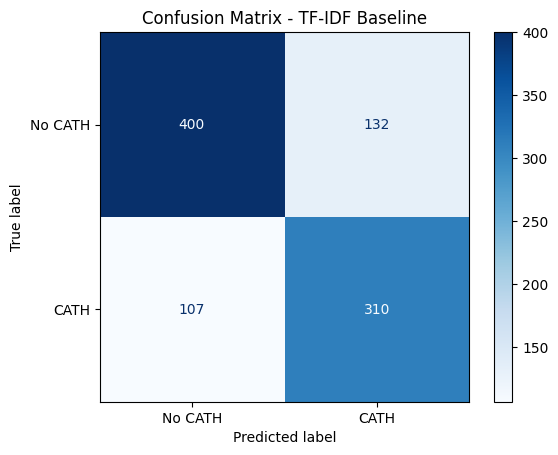

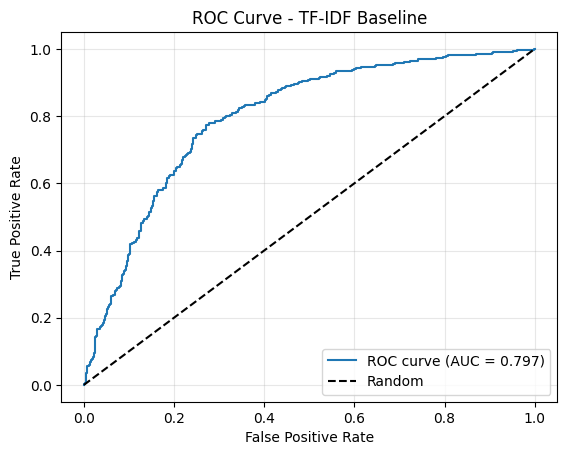

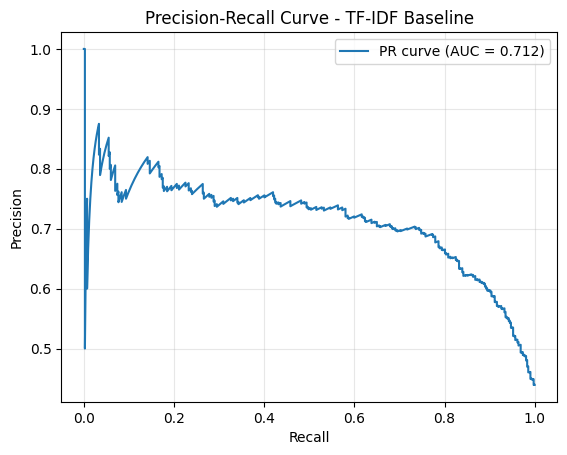


=== Summary Metrics ===
ROC-AUC: 0.797
PR-AUC: 0.712
Accuracy: 0.748

Results saved to results/


In [30]:
# Classification Report
print("\n Classification Report")
print(classification_report(test_df['cath_label'], y_pred_tfidf,
                            target_names=['No CATH', 'CATH']))

# Confusion Matrix
cm_tfidf = confusion_matrix(test_df['cath_label'], y_pred_tfidf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_tfidf,
                               display_labels=['No CATH', 'CATH'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - TF-IDF Baseline")
plt.show()

# ROC-AUC
roc_auc_tfidf = roc_auc_score(test_df['cath_label'], y_prob_tfidf)
fpr_tfidf, tpr_tfidf, _ = roc_curve(test_df['cath_label'], y_prob_tfidf)

plt.figure()
plt.plot(fpr_tfidf, tpr_tfidf, label=f'ROC curve (AUC = {roc_auc_tfidf:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - TF-IDF Baseline')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Precision-Recall Curve
precision_tfidf, recall_tfidf, _ = precision_recall_curve(
    test_df['cath_label'], y_prob_tfidf
)
pr_auc_tfidf = auc(recall_tfidf, precision_tfidf)

plt.figure()
plt.plot(recall_tfidf, precision_tfidf,
         label=f'PR curve (AUC = {pr_auc_tfidf:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - TF-IDF Baseline')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 5. Save results
results_tfidf = pd.DataFrame({
    'true_label': test_df['cath_label'].values,
    'pred_label': y_pred_tfidf,
    'prob_CATH': y_prob_tfidf
})
results_tfidf.to_csv(os.path.join(RESULTS_DIR, 'tfidf_baseline_pred.csv'), index=False)

# Save metrics
with open(os.path.join(RESULTS_DIR, 'tfidf_baseline_metrics.txt'), 'w') as f:
    f.write("=== TF-IDF Baseline Results ===\n")
    f.write(f"ROC-AUC: {roc_auc_tfidf:.3f}\n")
    f.write(f"PR-AUC: {pr_auc_tfidf:.3f}\n")
    f.write(f"Accuracy: {(test_df['cath_label'].values == y_pred_tfidf).mean():.3f}\n\n")
    f.write(classification_report(test_df['cath_label'], y_pred_tfidf,
                                   target_names=['No CATH', 'CATH']))

# Print summary
print("\n=== Summary Metrics ===")
print(f"ROC-AUC: {roc_auc_tfidf:.3f}")
print(f"PR-AUC: {pr_auc_tfidf:.3f}")
print(f"Accuracy: {(test_df['cath_label'].values == y_pred_tfidf).mean():.3f}")
print(f"\nResults saved to {RESULTS_DIR}/")

In [31]:
# Important features
print("\n=== Top 20 Most Important Features ===")
feature_names = vectorizer.get_feature_names_out()
coefficients = lr_model.coef_[0]

# Get top features for predicting CATH
top_positive_idx = coefficients.argsort()[-20:][::-1]
print("\nTop features predicting CATH:")
for idx in top_positive_idx:
    print(f"  {feature_names[idx]:30s} {coefficients[idx]:8.4f}")

# Get top features predicting NO CATH
top_negative_idx = coefficients.argsort()[:20]
print("\nTop features predicting NO CATH:")
for idx in top_negative_idx:
    print(f"  {feature_names[idx]:30s} {coefficients[idx]:8.4f}")


=== Top 20 Most Important Features ===

Top features predicting CATH:
  cath                             2.7956
  osh                              2.3101
  catheterization                  2.2665
  heparin                          2.1079
  plavix                           1.7813
  chest                            1.3881
  complaint chest                  1.3584
  pain physical                    1.3243
  cardiac catheterization          1.2768
  presented ___                    1.2280
  lab                              1.1891
  sao2                             1.1848
  femoral                          1.1789
  hyperlipidemia                   1.1706
  ___ ___                          1.1606
  cath lab                         1.1602
  diaphoresis                      1.1183
  st                               1.1146
  stress                           1.0986
  transferred                      1.0796

Top features predicting NO CATH:
  pe                              -1.2504
  lasix      

### Baseline 2: Simple Concatenate

**Possible options for your GPU constraints:**

- **BioBERT** (https://huggingface.co/dmis-lab/biobert-v1.1): Trained on PubMed + PMC articles (general biomedical)
- **ClinicalBERT** (https://huggingface.co/emilyalsentzer/Bio_ClinicalBERT): Trained on clinical notes (MIMIC data)
- **PubMedBERT** (https://huggingface.co/microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract-fulltext): similar to BioBERT but newer


In [32]:
from torch.utils.data import DataLoader
from torch.optim import AdamW
from torch.optim import SGD
from sklearn.metrics import f1_score, precision_score, recall_score

MODEL_NAME   = "emilyalsentzer/Bio_ClinicalBERT"
#MODEL_NAME   = "dmis-lab/biobert-v1.1"
NUM_LABELS   = 2
NUM_EPOCH    = 4
BATCH_SIZE   = 16
LR           = 2e-5
PATIENCE     = 3

In [33]:
device = 'cuda' if cuda.is_available() else 'cpu'

model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=NUM_LABELS, torch_dtype="auto")
model = model.to(device)
model

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at emilyalsentzer/Bio_ClinicalBERT and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(28996, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

In [34]:
# # Tokenizer
# tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# # Tokenize
# train_encodings = tokenizer(
#     train_df['model_input'].tolist(),
#     truncation=True,
#     padding=True,
#     max_length=512
# )

# test_encodings = tokenizer(
#     test_df['model_input'].tolist(),
#     truncation=True,
#     padding=True,
#     max_length=512
# )


In [35]:
# class CATHDataset(torch.utils.data.Dataset):
#     def __init__(self, encodings, labels):
#         self.encodings = encodings
#         self.labels = labels

#     def __getitem__(self, idx):
#         item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
#         item['labels'] = torch.tensor(self.labels[idx])
#         return item

#     def __len__(self):
#         return len(self.labels)

# train_dataset = CATHDataset(train_encodings, train_df['cath_label'].tolist())
# test_dataset = CATHDataset(test_encodings, test_df['cath_label'].tolist())


In [36]:
# # Create validation from training
# from torch.utils.data import random_split
# num_train = int(len(train_df)*0.8)

# generator = torch.Generator().manual_seed(RSEED)
# train_subset, val_subset = torch.utils.data.random_split(
#     train_dataset,
#     [num_train, len(train_df)-num_train],
#     generator=generator
#     )

# # Create dataloaders:
# train_loader = DataLoader(train_subset, batch_size=16, shuffle=True)
# val_loader = DataLoader(val_subset, batch_size=16, shuffle=False)
# test_loader = DataLoader(test_dataset, batch_size=16)

#### Training + Evaluation

In [37]:
class EarlyStopping:
    def __init__(self, patience=5, delta=0, verbose=False):
        self.patience = patience
        self.delta = delta
        self.verbose = verbose
        self.best_loss = None
        self.no_improvement_count = 0
        self.stop_training = False
        self.best_state_dict = None

    def check_early_stop(self, loss_valid, model):
        if self.best_loss is None or loss_valid < self.best_loss - self.delta:
            self.best_loss = loss_valid
            self.no_improvement_count = 0
            # Save a copy of the model's parameters.
            self.best_state_dict = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            self.no_improvement_count += 1
            if self.no_improvement_count >= self.patience:
                self.stop_training = True

In [71]:
def one_cycle(model, train_loader, val_loader, test_loader, num_epochs=NUM_EPOCH, device=device,
              train_df=train_df, learning_rate=LR, patience=PATIENCE,
              checkpoint_dir=CHECKPOINTS_DIR, results_dir=RESULTS_DIR, experiment_name='baseline'):
    """
    Args:
        model: PyTorch model to train
        train_loader, val_loader: DataLoaders
        num_epochs: Number of training epochs
        device: 'cuda' or 'cpu'
        train_df: Training dataframe (for class weights)
        learning_rate: Learning rate
        patience: Early stopping patience
        checkpoint_dir: Where to save checkpoints
        experiment_name: Name for this experiment (e.g., 'baseline', 'lora', 'kg')

    Returns:
        model: Trained model
        history: Dict with train/val losses and metrics
    """

    # CrossEntropyLoss combines softmax and negative log likelihood in one class
    class_0 = train_df['cath_label'].value_counts()[int(0)]
    class_1 = train_df['cath_label'].value_counts()[int(1)]
    total = class_0 + class_1
    class_weights = torch.tensor([total/(2*class_0), total/(2*class_1)], dtype=torch.float).to(device)

    # Define the loss function:
    criterion = torch.nn.CrossEntropyLoss(weight=class_weights).to(device)

    #optimizer:
    optimizer = AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-2) # ADJUST

    #scheduler:
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=learning_rate*2.5,
        steps_per_epoch=len(train_loader),
        epochs=num_epochs,
        pct_start=0.1, #warmup quicker
        anneal_strategy='cos'
    )

    # Initialize early stopping
    early_stopping = EarlyStopping(patience=patience, delta=0, verbose=True)

    # History tracking
    history = {
          'train_loss': [],
          'val_loss': [],
          'val_f1': [],
          'val_precision': [],
          'val_recall': []
    }


    for epoch in range(num_epochs):
      torch.cuda.empty_cache()
      model.train()
      train_losses = []
      for batch in tqdm(train_loader,desc=f"Epoch {epoch+1}/{num_epochs}"):
        optimizer.zero_grad()

        outputs = model(
          input_ids      = batch['input_ids'].to(device),
          attention_mask = batch['attention_mask'].to(device),
          labels         = batch['labels'].to(device)
        )

        loss = criterion(outputs.logits, batch['labels'].to(device))
        loss.backward()
        train_losses.append(loss.item())

        # Gradient clipping (if needed)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        scheduler.step()

      history['train_loss'].append(np.mean(train_losses))

      # Validation phase after each epoch
      model.eval()
      y_true, y_pred = [], []
      val_loss = 0.0
      total = 0

      with torch.no_grad():
          for batch in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
              val_outputs = model(
                  input_ids=batch['input_ids'].to(device),
                  attention_mask=batch['attention_mask'].to(device),
                  labels=batch['labels'].to(device)
              )

              vloss = criterion(val_outputs.logits, batch['labels'].to(device))
              val_loss += vloss.item() * batch['labels'].size(0)
              total += batch['labels'].size(0)

              #prediction
              _, predicted = torch.max(val_outputs.logits, 1)

              y_pred.extend(predicted.cpu().numpy())
              y_true.extend(batch['labels'].cpu().numpy())

      history['val_loss'].append(val_loss / total)
      history['val_f1'].append(f1_score(y_true, y_pred, average='macro'))
      history['val_precision'].append(precision_score(y_true, y_pred, average='macro'))
      history['val_recall'].append(recall_score(y_true, y_pred, average='macro'))


      print(f"Epoch {epoch+1}: Train Loss = {history['train_loss'][-1]:.3f}, "
            f"Val Loss: {history['val_loss'][-1]:.3f}, "
            f"F1: {history['val_f1'][-1]:.2f}, "
            f"Precision: {history['val_precision'][-1]:.2f}, "
            f"Recall: {history['val_recall'][-1]:.2f}")


      # Save checkpoint for the best model:
      if early_stopping.no_improvement_count == 0:
        checkpoint_path = os.path.join(checkpoint_dir, f'{experiment_name}_epoch_{epoch+1}.pt')
        torch.save({
            'epoch': epoch+1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_loss': history['train_loss'][-1],
            'val_loss': history['val_loss'][-1],
        }, checkpoint_path)

      # Early stopping check
      early_stopping.check_early_stop(history['val_loss'][-1], model)
      if early_stopping.stop_training:
          print(f"Stopping early at epoch {epoch+1}")
          break

    print('Finished Training')

    # Load best model after EarlyStopping
    if early_stopping.best_state_dict is not None:
        model.load_state_dict(early_stopping.best_state_dict)
        print("Loaded best model from early stopping")

    # Evaluation:
    model.eval()
    y_true, y_pred, y_prob = [], [], []
    with torch.no_grad():
      for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].cpu().numpy() # true labels
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        probs = torch.softmax(outputs.logits, dim=1).cpu().numpy()
        preds = np.argmax(probs, axis=1) # predicted labels

        y_true.extend(labels)
        y_pred.extend(preds)
        y_prob.extend(probs[:, 1])

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_prob = np.array(y_prob)

    # Plotting the loss curves
    plt.figure(figsize=(10, 5))
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Train and Validation Loss Curves')
    plt.show()

    # Classification report
    print("\n=== Classification Report ===")
    print(classification_report(y_true, y_pred, target_names=['No CATH', 'CATH']))

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No CATH', 'CATH'])
    disp.plot(cmap='Blues')
    plt.title("Confusion Matrix")
    plt.show()

    # ROC–AUC
    roc_auc = roc_auc_score(y_true, y_prob)
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    plt.figure()
    plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()
    plt.show()

    # --- Precision–Recall Curve ---
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    pr_auc = auc(recall, precision)
    plt.figure()
    plt.plot(recall, precision, label=f'PR curve (AUC = {pr_auc:.3f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision–Recall Curve')
    plt.legend()
    plt.show()

    # Save detailed predictions
    results_df = pd.DataFrame({
        'true_label': y_true,
        'pred_label': y_pred,
        'prob_CATH': y_prob
    })
    results_path = os.path.join(results_dir, f'{experiment_name}_pred.csv')
    results_df.to_csv(results_path, index=False)

    metrics_path = os.path.join(results_dir, f'{experiment_name}_metrics.txt')
    with open(metrics_path, "w") as f:
        f.write(f"=== Summary Metrics ({experiment_name}) ===\n")
        f.write(f"ROC-AUC: {roc_auc:.3f}\n")
        f.write(f"PR-AUC : {pr_auc:.3f}\n")
        f.write(f"Accuracy: {(y_true == y_pred).mean():.3f}\n\n")
        f.write(classification_report(y_true, y_pred, target_names=['No CATH', 'CATH']))

    # Print out the summary
    print("\n=== Summary Metrics ===")
    print(f"ROC-AUC: {roc_auc:.3f}")
    print(f"PR-AUC : {pr_auc:.3f}")
    print(f"Accuracy: {(y_true == y_pred).mean():.3f}")

    return model, history, y_true, y_pred, y_prob

In [39]:
# # Training model
# model, history, y_true, y_pred, y_prob = one_cycle(
#     model=model,
#     train_loader=train_loader,
#     val_loader=val_loader,
#     test_loader=test_loader,
#     num_epochs=NUM_EPOCH,
#     device=device,
#     train_df=train_df,
#     learning_rate=LR,
#     patience=PATIENCE,
#     experiment_name='baseline')


### LoRA

In [40]:
# from peft import LoraConfig, get_peft_model, TaskType

# lora_r = 8
# scaling_factor = 2
# lora_alpha = scaling_factor * lora_r

# def create_lora_model(model_name, num_labels, lora_r=lora_r, lora_alpha=lora_alpha, lora_dropout=0.1):
#     """
#     Create a RoBERTa model with LoRA adapters

#     Args:
#         model_name: Base model name (e.g., 'roberta-base')
#         num_labels: Number of classification labels
#         lora_r: LoRA rank
#         lora_alpha: LoRA alpha parameter
#         lora_dropout: Dropout for LoRA layers

#     Returns:
#         model: LoRA-enhanced model
#     """
#     # Load base model
#     base_model = AutoModelForSequenceClassification.from_pretrained(
#         model_name,
#         num_labels=num_labels
#     )

#     # LoRA configuration
#     lora_config = LoraConfig(
#         task_type=TaskType.SEQ_CLS,
#         r=lora_r,  # Rank - lower = fewer parameters
#         lora_alpha=lora_alpha,  # Scaling factor
#         lora_dropout=lora_dropout,
#         target_modules=["query", "value"],  # Which attention layers to adapt
#         bias="none"
#     )

#     # Apply LoRA
#     model = get_peft_model(base_model, lora_config)
#     model.print_trainable_parameters()  # Shows how many params are trainable

#     return model

# # Usage:
# # lora_r: [4, 8, 16, 32] - lower = faster/smaller, higher = more capacity
# model_lora = create_lora_model(MODEL_NAME, NUM_LABELS, lora_r=8, lora_alpha=16)
# model_lora = model_lora.to(device)

# # Train with LoRA
# # learning_rate: Try [1e-4, 3e-4, 5e-4] - higher than full fine-tuning
# trained_lora_model, lora_history, y_true, y_pred, y_prob = one_cycle(
#     model=model_lora,
#     train_loader=train_loader,
#     val_loader=val_loader,
#     test_loader=test_loader,
#     learning_rate=3e-4,  # Higher LR for LoRA
#     experiment_name='lora'
# )

### KG Simple

In [42]:
# Step 1: Build simple KG from your data
def build_knowledge_graph(train_df):
    """
    Build KG: ECG findings -> Diseases -> CATH likelihood
    """
    kg = {}

    # For each disease/diagnosis pattern, track CATH rate
    for idx, row in train_df.iterrows():
        # Extract key ECG findings (simplified)
        ecg_findings = row['ecg_text'].lower()

        # Key patterns
        patterns = {
            'st_elevation': 'st elevation' in ecg_findings or 'stemi' in ecg_findings,
            'infarct': 'infarct' in ecg_findings or 'no infarct': 'no infarct' in ecg_findings,
            'ischemia': 'ischemia' in ecg_findings or 'ischemic' in ecg_findings or 'no ischemia': 'no ischemia' in ecg_findings,
            'abnormal_ecg': 'abnormal ecg' in ecg_findings,
        }

        for pattern_name, pattern_found in patterns.items():
            if pattern_found:
                if pattern_name not in kg:
                    kg[pattern_name] = {'cath_count': 0, 'total': 0}
                kg[pattern_name]['total'] += 1
                if row['cath_label'] == 1:
                    kg[pattern_name]['cath_count'] += 1

    # Calculate CATH probability for each pattern
    for pattern in kg:
        kg[pattern]['cath_prob'] = kg[pattern]['cath_count'] / kg[pattern]['total']

    return kg

# Step 2: Add KG features to input
def add_kg_features(row, kg):
    """Add KG-derived features to model input"""
    ecg_lower = row['ecg_text'].lower()

    kg_info = []
    for pattern_name in kg:
        if pattern_name.replace('_', ' ') in ecg_lower:
            prob = kg[pattern_name]['cath_prob']
            kg_info.append(f"{pattern_name}: CATH_risk={prob:.2f}")

    kg_text = " | KG_Features: " + ", ".join(kg_info) if kg_info else ""

    # Original input + KG features
    text = f"Clinical History: {row['HPI']} "
    text += f"Physical Examination: {row['physical_exam']} "
    text += f"ECG Findings: {row['ecg_text']} "
    text += f"Troponin Status: {row['troponin_status']}"
    text += kg_text  # <-- ADD KG INFO

    return text

# Build KG from training data
kg = build_knowledge_graph(train_df)

# Create new dataset with KG features
train_df['model_input_kg'] = train_df.apply(lambda row: add_kg_features(row, kg), axis=1)
test_df['model_input_kg'] = test_df.apply(lambda row: add_kg_features(row, kg), axis=1)

In [43]:
# Tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Re-tokenize with KG-enhanced input
train_encodings_kg = tokenizer(
    train_df['model_input_kg'].tolist(),
    truncation=True,
    padding=True,
    max_length=512
)

test_encodings_kg = tokenizer(
    test_df['model_input_kg'].tolist(),
    truncation=True,
    padding=True,
    max_length=512
)

vocab.txt: 0.00B [00:00, ?B/s]

In [44]:
class CATHDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = CATHDataset(train_encodings_kg, train_df['cath_label'].tolist())
test_dataset = CATHDataset(test_encodings_kg, test_df['cath_label'].tolist())

# Create validation from training
from torch.utils.data import random_split
num_train = int(len(train_df)*0.8)

generator = torch.Generator().manual_seed(RSEED)
train_subset, val_subset = torch.utils.data.random_split(
    train_dataset,
    [num_train, len(train_df)-num_train],
    generator=generator
    )

# Create dataloaders:
train_loader_kg = DataLoader(train_subset, batch_size=16, shuffle=True)
val_loader_kg = DataLoader(val_subset, batch_size=16, shuffle=False)
test_loader_kg = DataLoader(test_dataset, batch_size=16)


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at emilyalsentzer/Bio_ClinicalBERT and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/4:   0%|          | 0/190 [00:00<?, ?it/s]

Epoch 1/4:   0%|          | 0/48 [00:00<?, ?it/s]

Epoch 1: Train Loss = 0.633, Val Loss: 0.599, F1: 0.71, Precision: 0.73, Recall: 0.71


Epoch 2/4:   0%|          | 0/190 [00:00<?, ?it/s]

...

Epoch 3/4:   0%|          | 0/48 [00:00<?, ?it/s]

Epoch 3: Train Loss = 0.456, Val Loss: 0.590, F1: 0.73, Precision: 0.74, Recall: 0.73


Epoch 4/4:   0%|          | 0/190 [00:00<?, ?it/s]

Epoch 4/4:   0%|          | 0/48 [00:00<?, ?it/s]

Epoch 4: Train Loss = 0.330, Val Loss: 0.631, F1: 0.74, Precision: 0.74, Recall: 0.74
Finished Training
Loaded best model from early stopping


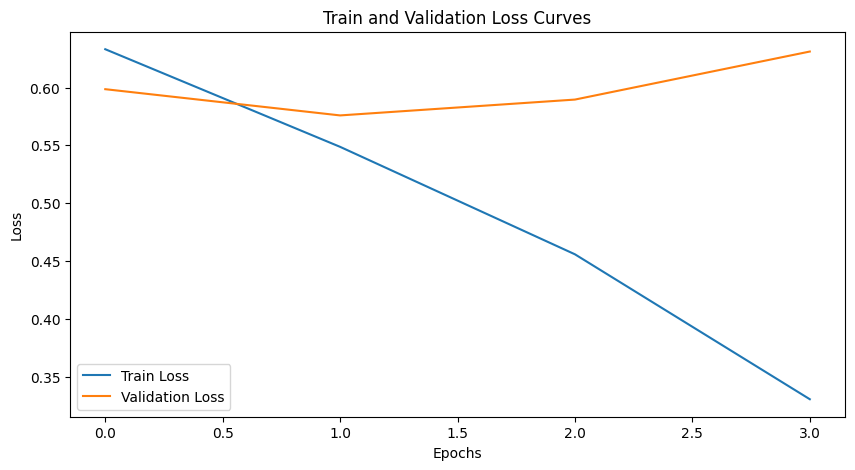


=== Classification Report ===
              precision    recall  f1-score   support

     No CATH       0.74      0.80      0.77       532
        CATH       0.72      0.64      0.68       417

    accuracy                           0.73       949
   macro avg       0.73      0.72      0.72       949
weighted avg       0.73      0.73      0.73       949



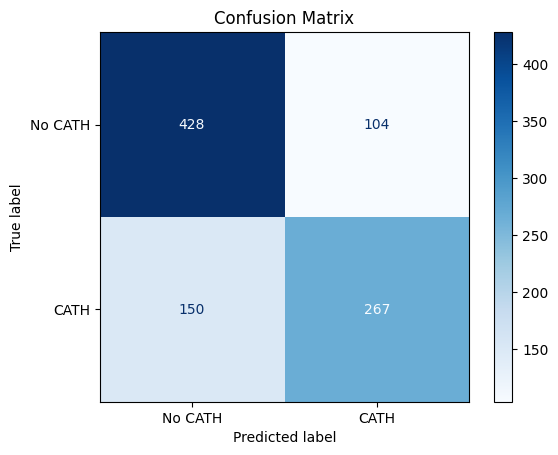

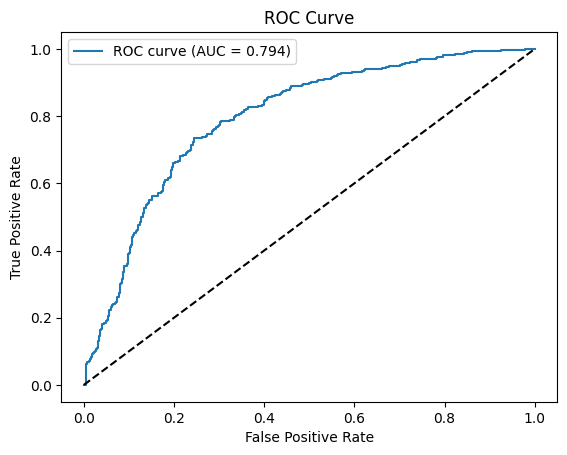

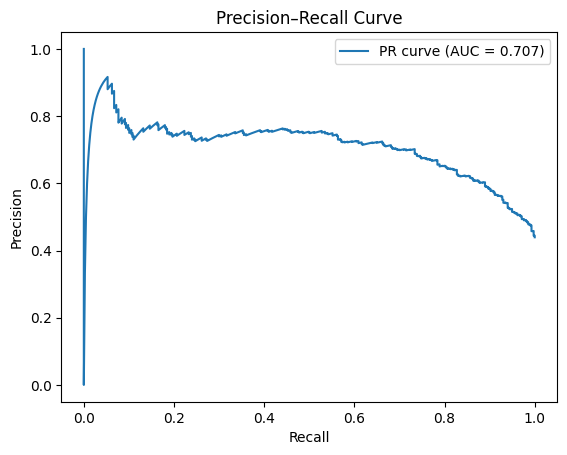


=== Summary Metrics ===
ROC-AUC: 0.794
PR-AUC : 0.707
Accuracy: 0.732


In [45]:
# Train:
model_kg = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2).to(device)

trained_kg_model, kg_history, y_true, y_pred, y_prob = one_cycle(
    model=model_kg,
    train_loader=train_loader_kg,
    val_loader=val_loader_kg,
    test_loader=test_loader_kg,
    experiment_name='with_kg'
)

### KG from ICD-10

In [63]:
import requests
import json
from collections import defaultdict
import re

In [54]:
# Step 1: Build KG with hierarchical relationships
def build_medical_kg():
    """
    Build hierarchical medical KG using ICD-10 and medical ontologies
    Structure: Symptoms -> Clinical Findings -> Diagnoses -> Procedures
    """
    kg = {
        'concepts': {},
        'relationships': defaultdict(list),
        'cath_evidence': {}
    }

    cardiac_ontology = {
        # SYMPTOMS (patient-reported)
        'chest_pain': {'parent': None, 'type': 'symptom', 'icd10': 'R07.9',
                       'aliases': ['chest discomfort', 'angina', 'chest pressure', 'substernal']},
        'shortness_of_breath': {'parent': None, 'type': 'symptom', 'icd10': 'R06.0',
                                'aliases': ['dyspnea', 'sob', 'difficulty breathing', 'breathlessness']},
        'palpitations': {'parent': None, 'type': 'symptom', 'icd10': 'R00.2',
                        'aliases': ['irregular heartbeat', 'heart racing', 'pounding']},
        'syncope': {'parent': None, 'type': 'symptom', 'icd10': 'R55',
                   'aliases': ['fainting', 'loss of consciousness', 'passing out']},
        'diaphoresis': {'parent': None, 'type': 'symptom', 'icd10': 'R61',
                       'aliases': ['sweating', 'profuse sweating', 'diaphoretic']},
        'nausea': {'parent': None, 'type': 'symptom', 'icd10': 'R11.0',
                  'aliases': ['nauseous', 'vomiting', 'emesis']},

        # CLINICAL FINDINGS (objective measurements)
        'st_elevation': {'parent': 'myocardial_ischemia', 'type': 'finding', 'icd10': 'I24.9',
                        'aliases': ['st segment elevation', 'stemi', 'st elevations']},
        'st_depression': {'parent': 'myocardial_ischemia', 'type': 'finding', 'icd10': 'I24.9',
                         'aliases': ['st segment depression', 'st depressions']},
        't_wave_inversion': {'parent': 'myocardial_ischemia', 'type': 'finding', 'icd10': 'I25.2',
                            'aliases': ['inverted t waves', 't wave abnormality', 't inversion']},
        'q_waves': {'parent': 'myocardial_infarction', 'type': 'finding', 'icd10': 'I21.9',
                   'aliases': ['pathological q waves', 'q wave', 'pathologic q']},
        'elevated_troponin': {'parent': 'myocardial_injury', 'type': 'finding', 'icd10': 'I21.4',
                             'aliases': ['troponin positive', 'abnormal troponin', 'elevated cardiac enzymes']},
        'left_bundle_branch_block': {'parent': 'conduction_abnormality', 'type': 'finding', 'icd10': 'I44.7',
                                     'aliases': ['lbbb', 'bundle branch block', 'left bbb']},
        'right_bundle_branch_block': {'parent': 'conduction_abnormality', 'type': 'finding', 'icd10': 'I45.10',
                                      'aliases': ['rbbb', 'right bbb']},
        'atrial_fibrillation': {'parent': 'arrhythmia', 'type': 'finding', 'icd10': 'I48.91',
                               'aliases': ['afib', 'a fib', 'atrial fib', 'af']},

        # DIAGNOSES (clinical interpretation)
        'myocardial_ischemia': {'parent': 'coronary_artery_disease', 'type': 'diagnosis', 'icd10': 'I25.9',
                               'aliases': ['cardiac ischemia', 'ischemia', 'ischemic']},
        'myocardial_infarction': {'parent': 'acute_coronary_syndrome', 'type': 'diagnosis', 'icd10': 'I21.9',
                                 'aliases': ['mi', 'heart attack', 'infarct', 'infarction', 'myocardial infarct']},
        'myocardial_injury': {'parent': 'acute_coronary_syndrome', 'type': 'diagnosis', 'icd10': 'I21.A9',
                             'aliases': ['cardiac injury', 'myocardial damage']},
        'acute_coronary_syndrome': {'parent': 'coronary_artery_disease', 'type': 'diagnosis', 'icd10': 'I24.9',
                                   'aliases': ['acs', 'acute coronary']},
        'coronary_artery_disease': {'parent': None, 'type': 'diagnosis', 'icd10': 'I25.10',
                                   'aliases': ['cad', 'coronary disease', 'coronary artery']},
        'unstable_angina': {'parent': 'acute_coronary_syndrome', 'type': 'diagnosis', 'icd10': 'I20.0',
                           'aliases': ['ua', 'unstable']},
        'conduction_abnormality': {'parent': None, 'type': 'diagnosis', 'icd10': 'I45.9',
                                  'aliases': ['conduction disorder', 'conduction defect']},
        'arrhythmia': {'parent': None, 'type': 'diagnosis', 'icd10': 'I49.9',
                      'aliases': ['dysrhythmia', 'irregular rhythm', 'rhythm abnormality']},
    }

    # Build relationships
    for concept, info in cardiac_ontology.items():
        kg['concepts'][concept] = info
        if info['parent']:
            kg['relationships'][info['parent']].append(concept)

    return kg, cardiac_ontology


def update_kg_with_training_data(kg, cardiac_ontology, train_df):
    """
    Update KG with evidence from training data
    Calculate: P(CATH | clinical_finding)
    """
    evidence = defaultdict(lambda: {'cath_count': 0, 'total': 0})

    for idx, row in train_df.iterrows():
        text_fields = (
            str(row['chief_complaint']).lower() + ' ' +
            str(row['HPI']).lower() + ' ' +
            str(row['ecg_text']).lower() + ' ' +
            str(row['physical_exam']).lower()
        )

        # Track which concepts were matched (avoid double counting)
        matched_this_patient = set()

        # Check for troponin
        if row['troponin_status'] in ['abnormal', 'normal']:
            troponin_key = 'elevated_troponin' if row['troponin_status'] == 'abnormal' else 'normal_troponin'
            if troponin_key not in matched_this_patient:
                evidence[troponin_key]['total'] += 1
                if row['cath_label'] == 1:
                    evidence[troponin_key]['cath_count'] += 1
                matched_this_patient.add(troponin_key)

        # Match concepts in text
        for concept, info in cardiac_ontology.items():
            if concept in matched_this_patient:
                continue

            # Check main concept name
            if concept.replace('_', ' ') in text_fields:
                evidence[concept]['total'] += 1
                if row['cath_label'] == 1:
                    evidence[concept]['cath_count'] += 1
                matched_this_patient.add(concept)
                continue

            # Check aliases
            for alias in info.get('aliases', []):
                if alias in text_fields:
                    evidence[concept]['total'] += 1
                    if row['cath_label'] == 1:
                        evidence[concept]['cath_count'] += 1
                    matched_this_patient.add(concept)
                    break

    # Calculate probabilities with Laplace smoothing
    for concept in evidence:
        total = evidence[concept]['total']
        cath_count = evidence[concept]['cath_count']
        kg['cath_evidence'][concept] = {
            'prob': (cath_count + 1) / (total + 2),
            'count': total,
            'confidence': min(total / 10, 1.0)
        }

    return kg

In [55]:
def aggregate_hierarchical_risk(matched_concepts, kg, cardiac_ontology):
    """
    Aggregate risk scores hierarchically:
    - If child findings present, propagate to parent diagnosis
    - Weight by confidence and hierarchical level
    """
    # Group by parent diagnosis
    diagnosis_risks = defaultdict(lambda: {'findings': [], 'max_risk': 0.0})

    for mc in matched_concepts:
        concept = mc['concept']
        parent = cardiac_ontology.get(concept, {}).get('parent')

        if parent:
            # This is a finding or symptom -> aggregate to parent
            diagnosis_risks[parent]['findings'].append(mc)
            diagnosis_risks[parent]['max_risk'] = max(
                diagnosis_risks[parent]['max_risk'],
                mc['prob']
            )
        else:
            # Top-level diagnosis
            diagnosis_risks[concept]['findings'].append(mc)
            diagnosis_risks[concept]['max_risk'] = max(
                diagnosis_risks[concept]['max_risk'],
                mc['prob']
            )

    # Build aggregated diagnosis list
    aggregated = []
    for diagnosis, data in diagnosis_risks.items():
        if data['findings']:
            # Average of child risks weighted by confidence
            weighted_risk = sum(f['prob'] * f['confidence'] for f in data['findings']) / \
                          max(sum(f['confidence'] for f in data['findings']), 0.1)

            aggregated.append({
                'diagnosis': diagnosis,
                'risk': weighted_risk,
                'max_risk': data['max_risk'],
                'num_findings': len(data['findings']),
                'findings': data['findings']
            })

    # Sort by risk
    aggregated.sort(key=lambda x: -x['risk'])
    return aggregated


def add_kg_features_hierarchical_smart(row, kg, cardiac_ontology):
    """
    Smart hierarchical KG features with aggressive truncation
    Priority: ECG > Troponin > Chief Complaint > Limited HPI > KG signals
    """
    text_fields = (
        str(row['chief_complaint']).lower() + ' ' +
        str(row['HPI']).lower() + ' ' +
        str(row['ecg_text']).lower() + ' ' +
        str(row['physical_exam']).lower()
    )

    matched_concepts = []

    # Find matching concepts
    for concept, info in cardiac_ontology.items():
        matched = False

        if concept.replace('_', ' ') in text_fields:
            matched = True

        if not matched:
            for alias in info.get('aliases', []):
                if alias in text_fields:
                    matched = True
                    break

        if matched and concept in kg['cath_evidence']:
            evidence = kg['cath_evidence'][concept]
            matched_concepts.append({
                'concept': concept,
                'type': info['type'],
                'prob': evidence['prob'],
                'confidence': evidence['confidence'],
                'icd10': info.get('icd10', 'N/A')
            })

    # Check troponin
    if row['troponin_status'] == 'abnormal' and 'elevated_troponin' in kg['cath_evidence']:
        evidence = kg['cath_evidence']['elevated_troponin']
        matched_concepts.append({
            'concept': 'elevated_troponin',
            'type': 'finding',
            'prob': evidence['prob'],
            'confidence': evidence['confidence'],
            'icd10': 'I21.4'
        })

    # Aggregate hierarchically
    aggregated = aggregate_hierarchical_risk(matched_concepts, kg, cardiac_ontology)

    # Build COMPACT hierarchical KG summary
    kg_summary = ""
    if aggregated:
        # Top 2 diagnoses with their key findings
        top_diagnoses = aggregated[:2]

        kg_parts = []
        for diag in top_diagnoses:
            # Get ICD code for diagnosis
            diag_info = cardiac_ontology.get(diag['diagnosis'], {})
            diag_icd = diag_info.get('icd10', 'N/A')

            # List top 2 findings
            finding_names = [f['concept'].replace('_', ' ') for f in diag['findings'][:2]]
            findings_str = ','.join(finding_names) if finding_names else diag['diagnosis']

            kg_parts.append(
                f"{diag['diagnosis'].replace('_', ' ')}[{diag_icd}]"
                f"({findings_str}→{diag['risk']:.2f})"
            )

        kg_summary = f" [KG: {' | '.join(kg_parts)}]"

    # SMART TRUNCATION: Prioritize critical medical info
    # 1. Chief Complaint (always full)
    # 2. ECG (always full - most diagnostic)
    # 3. Troponin (structured)
    # 4. Physical Exam (truncated to 100 chars)
    # 5. HPI (truncated to 150 chars - can be verbose)

    chief_complaint = str(row['chief_complaint'])
    ecg_text = str(row['ecg_text'])
    troponin = row['troponin_status']

    # Truncate verbose fields
    physical_exam = str(row['physical_exam'])[:100] + "..." if len(str(row['physical_exam'])) > 100 else str(row['physical_exam'])
    hpi = str(row['HPI'])[:150] + "..." if len(str(row['HPI'])) > 150 else str(row['HPI'])

    # Assemble in priority order
    text = f"CC: {chief_complaint} | "
    text += f"ECG: {ecg_text} | "
    text += f"Trop: {troponin} | "
    text += f"Exam: {physical_exam} | "
    text += f"HPI: {hpi}"
    text += kg_summary

    return text

In [56]:
# Build medical KG
print("Building medical knowledge graph...")
kg, cardiac_ontology = build_medical_kg()

print("Updating KG with training evidence...")
kg = update_kg_with_training_data(kg, cardiac_ontology, train_df)

# Display KG statistics
print(f"\nKG Statistics:")
print(f"Total concepts: {len(kg['concepts'])}")
print(f"Concepts with evidence: {len(kg['cath_evidence'])}")
print("\nTop 10 concepts by CATH risk:")
sorted_evidence = sorted(kg['cath_evidence'].items(), key=lambda x: x[1]['prob'], reverse=True)
for concept, evidence in sorted_evidence[:10]:
    print(f"  {concept:30s}: {evidence['prob']:.2%} (n={evidence['count']:4d}, conf={evidence['confidence']:.2f})")

# Show hierarchical relationships
print("\nHierarchical Relationships (Parent → Children):")
for parent, children in sorted(kg['relationships'].items()):
    print(f"  {parent} → {', '.join(children)}")

# Create dataset with hierarchical KG features
print("\nEnhancing inputs with hierarchical KG features...")
train_df['model_input_kg_icd'] = train_df.apply(
    lambda row: add_kg_features_hierarchical_smart(row, kg, cardiac_ontology), axis=1
)
test_df['model_input_kg_icd'] = test_df.apply(
    lambda row: add_kg_features_hierarchical_smart(row, kg, cardiac_ontology), axis=1
)

print("\nSample KG-enhanced input (first 3 examples):")
for i in range(min(3, len(train_df))):
    print(f"\n--- Example {i+1} ---")
    print(train_df['model_input_kg_icd'].iloc[i])
    print(f"Label: {'CATH' if train_df['cath_label'].iloc[i] == 1 else 'No CATH'}")


Building medical knowledge graph...
Updating KG with training evidence...

KG Statistics:
Total concepts: 22
Concepts with evidence: 22

Top 10 concepts by CATH risk:
  myocardial_injury             : 64.00% (n= 123, conf=1.00)
  st_elevation                  : 62.86% (n=1137, conf=1.00)
  st_depression                 : 60.67% (n= 532, conf=1.00)
  diaphoresis                   : 58.25% (n=1059, conf=1.00)
  q_waves                       : 57.07% (n= 394, conf=1.00)
  t_wave_inversion              : 56.55% (n= 288, conf=1.00)
  conduction_abnormality        : 52.32% (n= 235, conf=1.00)
  elevated_troponin             : 51.31% (n=1951, conf=1.00)
  myocardial_ischemia           : 51.00% (n=1494, conf=1.00)
  acute_coronary_syndrome       : 49.76% (n= 207, conf=1.00)

Hierarchical Relationships (Parent → Children):
  acute_coronary_syndrome → myocardial_infarction, myocardial_injury, unstable_angina
  arrhythmia → atrial_fibrillation
  conduction_abnormality → left_bundle_branch_block, 

In [58]:
# Check token lengths BEFORE training
print("\n=== Token Length Analysis ===")
sample_inputs = train_df['model_input_kg_icd'].head(20).tolist()
token_lengths = []
for i, text in enumerate(sample_inputs):
    tokens = tokenizer.tokenize(text)
    token_lengths.append(len(tokens))
    if i < 5:  # Show first 5
        print(f"Sample {i+1}: {len(tokens)} tokens", end="")
        if len(tokens) > 512:
            print(f" ⚠️ TRUNCATED! Losing {len(tokens)-512} tokens")
        else:
            print(f" ✓")

print(f"\nToken length stats:")
print(f"  Mean: {np.mean(token_lengths):.0f}")
print(f"  Median: {np.median(token_lengths):.0f}")
print(f"  Max: {max(token_lengths)}")
print(f"  % over 512: {sum(1 for x in token_lengths if x > 512) / len(token_lengths) * 100:.1f}%")

print(f"\nAverage input length: {train_df['model_input_kg_icd'].str.len().mean():.0f} chars")



=== Token Length Analysis ===
Sample 1: 213 tokens ✓
Sample 2: 324 tokens ✓
Sample 3: 305 tokens ✓
Sample 4: 339 tokens ✓
Sample 5: 288 tokens ✓

Token length stats:
  Mean: 249
  Median: 226
  Max: 439
  % over 512: 0.0%

Average input length: 825 chars


In [59]:
# Initialize tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Re-tokenize with KG-enhanced input
train_encodings_kg_icd = tokenizer(
    train_df['model_input_kg_icd'].tolist(),
    truncation=True,
    padding=True,
    max_length=512
)

test_encodings_kg_icd = tokenizer(
    test_df['model_input_kg_icd'].tolist(),
    truncation=True,
    padding=True,
    max_length=512
)

In [61]:
train_dataset_icd = CATHDataset(train_encodings_kg_icd, train_df['cath_label'].tolist())
test_dataset_icd = CATHDataset(test_encodings_kg_icd, test_df['cath_label'].tolist())

# Create validation from training
num_train = int(len(train_df)*0.8)

generator = torch.Generator().manual_seed(RSEED)
train_subset_icd, val_subset_icd = torch.utils.data.random_split(
    train_dataset_icd,
    [num_train, len(train_df)-num_train],
    generator=generator
    )

# Create dataloaders:
train_loader_kg_icd = DataLoader(train_subset_icd, batch_size=16, shuffle=True)
val_loader_kg_icd = DataLoader(val_subset_icd, batch_size=16, shuffle=False)
test_loader_kg_icd = DataLoader(test_dataset_icd, batch_size=16)

In [62]:
# Train:
model_kg_icd = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    hidden_dropout_prob=0.3,      # Add dropout to avoid overfitting
    attention_probs_dropout_prob=0.2
).to(device)

LR_KG = 1e-5 # half of baseline

trained_kg_icd_model, kg_icd_history, y_icd_true, y_icd_pred, y_icd_prob = one_cycle(
    model=model_kg_icd,
    train_loader=train_loader_kg_icd,
    val_loader=val_loader_kg_icd,
    test_loader=test_loader_kg_icd,
    learning_rate=LR_KG,
    experiment_name='with_kg_icd'
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at emilyalsentzer/Bio_ClinicalBERT and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/4:   0%|          | 0/190 [00:00<?, ?it/s]

Epoch 1/4:   0%|          | 0/48 [00:00<?, ?it/s]

Epoch 1: Train Loss = 0.683, Val Loss: 0.655, F1: 0.63, Precision: 0.63, Recall: 0.63


Epoch 2/4:   0%|          | 0/190 [00:00<?, ?it/s]

...

Epoch 3/4:   0%|          | 0/190 [00:00<?, ?it/s]

Epoch 3/4:   0%|          | 0/48 [00:00<?, ?it/s]

Epoch 3: Train Loss = 0.594, Val Loss: 0.645, F1: 0.66, Precision: 0.67, Recall: 0.66


Epoch 4/4:   0%|          | 0/190 [00:00<?, ?it/s]

KeyboardInterrupt: 

## Smart Retrieval

In [64]:
# Step 1: Build KG with hierarchical relationships
def build_medical_kg():
    """
    Build hierarchical medical KG using ICD-10 and medical ontologies
    Structure: Symptoms -> Clinical Findings -> Diagnoses -> Procedures
    """
    kg = {
        'concepts': {},
        'relationships': defaultdict(list),
        'cath_evidence': {}
    }

    cardiac_ontology = {
        # SYMPTOMS (patient-reported)
        'chest_pain': {'parent': None, 'type': 'symptom', 'icd10': 'R07.9',
                       'aliases': ['chest discomfort', 'angina', 'chest pressure', 'substernal', 'precordial']},
        'shortness_of_breath': {'parent': None, 'type': 'symptom', 'icd10': 'R06.0',
                                'aliases': ['dyspnea', 'sob', 'difficulty breathing', 'breathlessness']},
        'palpitations': {'parent': None, 'type': 'symptom', 'icd10': 'R00.2',
                        'aliases': ['irregular heartbeat', 'heart racing', 'pounding']},
        'syncope': {'parent': None, 'type': 'symptom', 'icd10': 'R55',
                   'aliases': ['fainting', 'loss of consciousness', 'passing out']},
        'diaphoresis': {'parent': None, 'type': 'symptom', 'icd10': 'R61',
                       'aliases': ['sweating', 'profuse sweating', 'diaphoretic']},
        'nausea': {'parent': None, 'type': 'symptom', 'icd10': 'R11.0',
                  'aliases': ['nauseous', 'vomiting', 'emesis']},

        # CLINICAL FINDINGS (objective measurements)
        'st_elevation': {'parent': 'myocardial_ischemia', 'type': 'finding', 'icd10': 'I24.9',
                        'aliases': ['st segment elevation', 'stemi', 'st elevations']},
        'st_depression': {'parent': 'myocardial_ischemia', 'type': 'finding', 'icd10': 'I24.9',
                         'aliases': ['st segment depression', 'st depressions']},
        't_wave_inversion': {'parent': 'myocardial_ischemia', 'type': 'finding', 'icd10': 'I25.2',
                            'aliases': ['inverted t waves', 't wave abnormality', 't inversion']},
        'q_waves': {'parent': 'myocardial_infarction', 'type': 'finding', 'icd10': 'I21.9',
                   'aliases': ['pathological q waves', 'q wave', 'pathologic q']},
        'elevated_troponin': {'parent': 'myocardial_injury', 'type': 'finding', 'icd10': 'I21.4',
                             'aliases': ['troponin positive', 'abnormal troponin', 'elevated cardiac enzymes']},
        'left_bundle_branch_block': {'parent': 'conduction_abnormality', 'type': 'finding', 'icd10': 'I44.7',
                                     'aliases': ['lbbb', 'bundle branch block', 'left bbb']},
        'right_bundle_branch_block': {'parent': 'conduction_abnormality', 'type': 'finding', 'icd10': 'I45.10',
                                      'aliases': ['rbbb', 'right bbb']},
        'atrial_fibrillation': {'parent': 'arrhythmia', 'type': 'finding', 'icd10': 'I48.91',
                               'aliases': ['afib', 'a fib', 'atrial fib', 'af']},

        # DIAGNOSES (clinical interpretation)
        'myocardial_ischemia': {'parent': 'coronary_artery_disease', 'type': 'diagnosis', 'icd10': 'I25.9',
                               'aliases': ['cardiac ischemia', 'ischemia', 'ischemic']},
        'myocardial_infarction': {'parent': 'acute_coronary_syndrome', 'type': 'diagnosis', 'icd10': 'I21.9',
                                 'aliases': ['mi', 'heart attack', 'infarct', 'infarction', 'myocardial infarct']},
        'myocardial_injury': {'parent': 'acute_coronary_syndrome', 'type': 'diagnosis', 'icd10': 'I21.A9',
                             'aliases': ['cardiac injury', 'myocardial damage']},
        'acute_coronary_syndrome': {'parent': 'coronary_artery_disease', 'type': 'diagnosis', 'icd10': 'I24.9',
                                   'aliases': ['acs', 'acute coronary']},
        'coronary_artery_disease': {'parent': None, 'type': 'diagnosis', 'icd10': 'I25.10',
                                   'aliases': ['cad', 'coronary disease', 'coronary artery']},
        'unstable_angina': {'parent': 'acute_coronary_syndrome', 'type': 'diagnosis', 'icd10': 'I20.0',
                           'aliases': ['ua', 'unstable']},
        'conduction_abnormality': {'parent': None, 'type': 'diagnosis', 'icd10': 'I45.9',
                                  'aliases': ['conduction disorder', 'conduction defect']},
        'arrhythmia': {'parent': None, 'type': 'diagnosis', 'icd10': 'I49.9',
                      'aliases': ['dysrhythmia', 'irregular rhythm', 'rhythm abnormality']},
    }

    # Build relationships
    for concept, info in cardiac_ontology.items():
        kg['concepts'][concept] = info
        if info['parent']:
            kg['relationships'][info['parent']].append(concept)

    return kg, cardiac_ontology


def update_kg_with_training_data(kg, cardiac_ontology, train_df):
    """
    Update KG with evidence from training data
    Calculate: P(CATH | clinical_finding)
    """
    evidence = defaultdict(lambda: {'cath_count': 0, 'total': 0})

    for idx, row in train_df.iterrows():
        text_fields = (
            str(row['chief_complaint']).lower() + ' ' +
            str(row['HPI']).lower() + ' ' +
            str(row['ecg_text']).lower() + ' ' +
            str(row['physical_exam']).lower()
        )

        # Track which concepts were matched (avoid double counting)
        matched_this_patient = set()

        # Check for troponin
        if row['troponin_status'] in ['abnormal', 'normal']:
            troponin_key = 'elevated_troponin' if row['troponin_status'] == 'abnormal' else 'normal_troponin'
            if troponin_key not in matched_this_patient:
                evidence[troponin_key]['total'] += 1
                if row['cath_label'] == 1:
                    evidence[troponin_key]['cath_count'] += 1
                matched_this_patient.add(troponin_key)

        # Match concepts in text
        for concept, info in cardiac_ontology.items():
            if concept in matched_this_patient:
                continue

            # Check main concept name
            if concept.replace('_', ' ') in text_fields:
                evidence[concept]['total'] += 1
                if row['cath_label'] == 1:
                    evidence[concept]['cath_count'] += 1
                matched_this_patient.add(concept)
                continue

            # Check aliases
            for alias in info.get('aliases', []):
                if alias in text_fields:
                    evidence[concept]['total'] += 1
                    if row['cath_label'] == 1:
                        evidence[concept]['cath_count'] += 1
                    matched_this_patient.add(concept)
                    break

    # Calculate probabilities with Laplace smoothing
    for concept in evidence:
        total = evidence[concept]['total']
        cath_count = evidence[concept]['cath_count']
        kg['cath_evidence'][concept] = {
            'prob': (cath_count + 1) / (total + 2),
            'count': total,
            'confidence': min(total / 10, 1.0)
        }

    return kg


def extract_key_sentences(text, max_chars=300):
    """
    Extract key sentences containing medical keywords
    Priority: symptoms, timing, severity, medical history
    """
    if not text or len(str(text)) < 50:
        return str(text)

    text = str(text)

    # Split into sentences (rough)
    sentences = re.split(r'[.!?]\s+', text)

    # Keywords indicating important information
    high_priority_keywords = [
        'chest', 'pain', 'stemi', 'mi', 'infarct', 'ischemi', 'troponin',
        'angina', 'shortness', 'breath', 'hour', 'day', 'sudden', 'acute',
        'radiation', 'jaw', 'arm', 'severe', 'crushing', 'pressure',
        'diaphoresis', 'nausea', 'vomit', 'syncope', 'dizz'
    ]

    # Score each sentence
    scored_sentences = []
    for sent in sentences:
        sent = sent.strip()
        if len(sent) < 10:
            continue

        sent_lower = sent.lower()
        score = sum(1 for kw in high_priority_keywords if kw in sent_lower)
        scored_sentences.append((score, sent))

    # Sort by score and take top sentences
    scored_sentences.sort(key=lambda x: -x[0])

    # Build result within max_chars
    result = []
    current_length = 0
    for score, sent in scored_sentences:
        if current_length + len(sent) + 2 <= max_chars:  # +2 for ". "
            result.append(sent)
            current_length += len(sent) + 2
        else:
            # Add partial sentence if room
            remaining = max_chars - current_length - 3  # -3 for "..."
            if remaining > 30:
                result.append(sent[:remaining] + "...")
            break

    return '. '.join(result) if result else text[:max_chars]


def extract_vital_exam_findings(exam_text, max_chars=200):
    """
    Extract vital signs and key cardiac exam findings
    """
    if not exam_text or len(str(exam_text)) < 30:
        return str(exam_text)

    exam_text = str(exam_text)

    # Keywords for vital signs and cardiac exam
    vital_keywords = [
        'bp', 'blood pressure', 'hr', 'heart rate', 'pulse', 'temp', 'rr',
        'respiratory rate', 'o2', 'oxygen', 'sat', 'murmur', 'rhythm',
        'regular', 'irregular', 'gallop', 'rub', 'chest', 'lung', 'clear',
        'crackles', 'edema', 'jugular', 'jvd'
    ]

    sentences = re.split(r'[.!?]\s+', exam_text)

    scored_sentences = []
    for sent in sentences:
        sent = sent.strip()
        if len(sent) < 10:
            continue

        sent_lower = sent.lower()
        score = sum(1 for kw in vital_keywords if kw in sent_lower)
        scored_sentences.append((score, sent))

    scored_sentences.sort(key=lambda x: -x[0])

    result = []
    current_length = 0
    for score, sent in scored_sentences:
        if current_length + len(sent) + 2 <= max_chars:
            result.append(sent)
            current_length += len(sent) + 2
        else:
            remaining = max_chars - current_length - 3
            if remaining > 20:
                result.append(sent[:remaining] + "...")
            break

    return '. '.join(result) if result else exam_text[:max_chars]

In [65]:
def aggregate_hierarchical_risk(matched_concepts, kg, cardiac_ontology):
    """
    Aggregate risk scores hierarchically:
    - If child findings present, propagate to parent diagnosis
    - Weight by confidence and hierarchical level
    """
    diagnosis_risks = defaultdict(lambda: {'findings': [], 'max_risk': 0.0})

    for mc in matched_concepts:
        concept = mc['concept']
        parent = cardiac_ontology.get(concept, {}).get('parent')

        if parent:
            diagnosis_risks[parent]['findings'].append(mc)
            diagnosis_risks[parent]['max_risk'] = max(
                diagnosis_risks[parent]['max_risk'],
                mc['prob']
            )
        else:
            diagnosis_risks[concept]['findings'].append(mc)
            diagnosis_risks[concept]['max_risk'] = max(
                diagnosis_risks[concept]['max_risk'],
                mc['prob']
            )

    aggregated = []
    for diagnosis, data in diagnosis_risks.items():
        if data['findings']:
            weighted_risk = sum(f['prob'] * f['confidence'] for f in data['findings']) / \
                          max(sum(f['confidence'] for f in data['findings']), 0.1)

            aggregated.append({
                'diagnosis': diagnosis,
                'risk': weighted_risk,
                'max_risk': data['max_risk'],
                'num_findings': len(data['findings']),
                'findings': data['findings']
            })

    aggregated.sort(key=lambda x: -x['risk'])
    return aggregated

In [66]:
def add_kg_features_hierarchical_balanced(row, kg, cardiac_ontology):
    """
    BALANCED approach: Keep medical context + add KG hierarchy
    - Don't over-truncate clinical text
    - Add compact KG signals as structured metadata
    """
    text_fields = (
        str(row['chief_complaint']).lower() + ' ' +
        str(row['HPI']).lower() + ' ' +
        str(row['ecg_text']).lower() + ' ' +
        str(row['physical_exam']).lower()
    )

    matched_concepts = []

    # Find matching concepts
    for concept, info in cardiac_ontology.items():
        matched = False

        if concept.replace('_', ' ') in text_fields:
            matched = True

        if not matched:
            for alias in info.get('aliases', []):
                if alias in text_fields:
                    matched = True
                    break

        if matched and concept in kg['cath_evidence']:
            evidence = kg['cath_evidence'][concept]
            matched_concepts.append({
                'concept': concept,
                'type': info['type'],
                'prob': evidence['prob'],
                'confidence': evidence['confidence'],
                'icd10': info.get('icd10', 'N/A')
            })

    # Check troponin
    if row['troponin_status'] == 'abnormal' and 'elevated_troponin' in kg['cath_evidence']:
        evidence = kg['cath_evidence']['elevated_troponin']
        matched_concepts.append({
            'concept': 'elevated_troponin',
            'type': 'finding',
            'prob': evidence['prob'],
            'confidence': evidence['confidence'],
            'icd10': 'I21.4'
        })

    # Aggregate hierarchically
    aggregated = aggregate_hierarchical_risk(matched_concepts, kg, cardiac_ontology)

    # Build KG summary with hierarchy
    kg_summary = ""
    if aggregated:
        top_diagnoses = aggregated[:2]

        kg_parts = []
        for diag in top_diagnoses:
            diag_info = cardiac_ontology.get(diag['diagnosis'], {})
            diag_icd = diag_info.get('icd10', 'N/A')

            # Show findings hierarchy
            finding_names = [f['concept'].replace('_', ' ') for f in diag['findings'][:2]]
            findings_str = '+'.join(finding_names) if finding_names else diag['diagnosis']

            kg_parts.append(f"{findings_str}→{diag['diagnosis'].replace('_', ' ')}[{diag_icd}]:{diag['risk']:.2f}")

        kg_summary = f" [KG:{' | '.join(kg_parts)}]"

    # SMART extraction: Keep key medical content
    chief_complaint = str(row['chief_complaint'])
    ecg_text = str(row['ecg_text'])
    troponin = row['troponin_status']

    # Extract KEY parts from HPI and exam (don't just truncate)
    hpi_key = extract_key_sentences(row['HPI'], max_chars=250)
    exam_key = extract_vital_exam_findings(row['physical_exam'], max_chars=150)

    # Assemble with clear structure
    text = f"Chief Complaint: {chief_complaint} | "
    text += f"History: {hpi_key} | "
    text += f"ECG: {ecg_text} | "
    text += f"Exam: {exam_key} | "
    text += f"Troponin: {troponin}"
    text += kg_summary

    return text

In [67]:
# Build medical KG
print("Building medical knowledge graph...")
kg, cardiac_ontology = build_medical_kg()

print("Updating KG with training evidence...")
kg = update_kg_with_training_data(kg, cardiac_ontology, train_df)

# Display KG statistics
print(f"\nKG Statistics:")
print(f"Total concepts: {len(kg['concepts'])}")
print(f"Concepts with evidence: {len(kg['cath_evidence'])}")
print("\nTop 10 concepts by CATH risk:")
sorted_evidence = sorted(kg['cath_evidence'].items(), key=lambda x: x[1]['prob'], reverse=True)
for concept, evidence in sorted_evidence[:10]:
    print(f"  {concept:30s}: {evidence['prob']:.2%} (n={evidence['count']:4d}, conf={evidence['confidence']:.2f})")

# Show hierarchical relationships
print("\nHierarchical Relationships (Parent → Children):")
for parent, children in sorted(kg['relationships'].items()):
    print(f"  {parent} → {', '.join(children)}")

# Create dataset with BALANCED KG features
print("\nEnhancing inputs with balanced hierarchical KG features...")
train_df['model_input_kg_icd'] = train_df.apply(
    lambda row: add_kg_features_hierarchical_balanced(row, kg, cardiac_ontology), axis=1
)
test_df['model_input_kg_icd'] = test_df.apply(
    lambda row: add_kg_features_hierarchical_balanced(row, kg, cardiac_ontology), axis=1
)

print("\nSample KG-enhanced input (first 3 examples):")
for i in range(min(3, len(train_df))):
    print(f"\n--- Example {i+1} ---")
    print(train_df['model_input_kg_icd'].iloc[i][:600])  # Show more
    print(f"Label: {'CATH' if train_df['cath_label'].iloc[i] == 1 else 'No CATH'}")


Building medical knowledge graph...
Updating KG with training evidence...

KG Statistics:
Total concepts: 22
Concepts with evidence: 22

Top 10 concepts by CATH risk:
  myocardial_injury             : 64.00% (n= 123, conf=1.00)
  st_elevation                  : 62.86% (n=1137, conf=1.00)
  st_depression                 : 60.67% (n= 532, conf=1.00)
  diaphoresis                   : 58.25% (n=1059, conf=1.00)
  q_waves                       : 57.07% (n= 394, conf=1.00)
  t_wave_inversion              : 56.55% (n= 288, conf=1.00)
  conduction_abnormality        : 52.32% (n= 235, conf=1.00)
  elevated_troponin             : 51.31% (n=1951, conf=1.00)
  myocardial_ischemia           : 51.00% (n=1494, conf=1.00)
  acute_coronary_syndrome       : 49.76% (n= 207, conf=1.00)

Hierarchical Relationships (Parent → Children):
  acute_coronary_syndrome → myocardial_infarction, myocardial_injury, unstable_angina
  arrhythmia → atrial_fibrillation
  conduction_abnormality → left_bundle_branch_block, 

In [68]:
# Check token lengths BEFORE training
print("\n=== Token Length Analysis ===")
sample_inputs = train_df['model_input_kg_icd'].head(20).tolist()
token_lengths = []
for i, text in enumerate(sample_inputs):
    tokens = tokenizer.tokenize(text)
    token_lengths.append(len(tokens))
    if i < 5:
        print(f"Sample {i+1}: {len(tokens)} tokens", end="")
        if len(tokens) > 512:
            print(f" ⚠️ TRUNCATED! Losing {len(tokens)-512} tokens")
        else:
            print(f" ✓")

print(f"\nToken length stats:")
print(f"  Mean: {np.mean(token_lengths):.0f}")
print(f"  Median: {np.median(token_lengths):.0f}")
print(f"  Max: {max(token_lengths)}")
print(f"  % over 512: {sum(1 for x in token_lengths if x > 512) / len(token_lengths) * 100:.1f}%")

print(f"\nAverage input length: {train_df['model_input_kg_icd'].str.len().mean():.0f} chars")


=== Token Length Analysis ===
Sample 1: 228 tokens ✓
Sample 2: 343 tokens ✓
Sample 3: 341 tokens ✓
Sample 4: 364 tokens ✓
Sample 5: 315 tokens ✓

Token length stats:
  Mean: 279
  Median: 262
  Max: 479
  % over 512: 0.0%

Average input length: 978 chars


In [69]:
# Initialize tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Tokenize with balanced KG-enhanced input
train_encodings_kg_icd = tokenizer(
    train_df['model_input_kg_icd'].tolist(),
    truncation=True,
    padding=True,
    max_length=512
)

test_encodings_kg_icd = tokenizer(
    test_df['model_input_kg_icd'].tolist(),
    truncation=True,
    padding=True,
    max_length=512
)

# Create datasets
train_dataset_icd = CATHDataset(train_encodings_kg_icd, train_df['cath_label'].tolist())
test_dataset_icd = CATHDataset(test_encodings_kg_icd, test_df['cath_label'].tolist())

# Create validation split
num_train = int(len(train_df)*0.8)
generator = torch.Generator().manual_seed(RSEED)
train_subset_icd, val_subset_icd = torch.utils.data.random_split(
    train_dataset_icd,
    [num_train, len(train_df)-num_train],
    generator=generator
)

# Create dataloaders
train_loader_kg_icd = DataLoader(train_subset_icd, batch_size=16, shuffle=True)
val_loader_kg_icd = DataLoader(val_subset_icd, batch_size=16, shuffle=False)
test_loader_kg_icd = DataLoader(test_dataset_icd, batch_size=16)

In [72]:
# Initialize FRESH model with moderate dropout
model_kg_icd = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    hidden_dropout_prob=0.3,
    attention_probs_dropout_prob=0.2
).to(device)


NUM_EPOCH_KG = 4     # Moderate epochs
PATIENCE_KG = 3      # Early stopping
LR_KG = 2e-5         # SAME as baseline

trained_kg_icd_model, kg_icd_history, y_true_icd, y_pred_icd, y_prob_icd = one_cycle(
    model=model_kg_icd,
    train_loader=train_loader_kg_icd,
    val_loader=val_loader_kg_icd,
    test_loader=test_loader_kg_icd,
    num_epochs=NUM_EPOCH_KG,
    learning_rate=LR_KG,
    patience=PATIENCE_KG,
    experiment_name='with_kg_icd_hierarchical_v2'
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at emilyalsentzer/Bio_ClinicalBERT and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


OutOfMemoryError: CUDA out of memory. Tried to allocate 86.00 MiB. GPU 0 has a total capacity of 14.74 GiB of which 4.12 MiB is free. Process 4138 has 14.73 GiB memory in use. Of the allocated memory 14.26 GiB is allocated by PyTorch, and 353.64 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)